# ceol-gpt — Colab Training Notebook

**Before running:** In the Colab menu go to `Runtime → Change runtime type` and select **A100 GPU** or **H100 GPU**.

This notebook:
1. Mounts Drive and clones / pulls the repo
2. Installs dependencies
3. Verifies the GPU and tokenizer
4. Runs training (with automatic resume if the session drops)
5. Plots training curves from the saved log
6. Runs a quick generation sanity-check from the best checkpoint

## 0 — Mount Drive & clone repo

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# ── Edit this path to wherever you keep the repo in your Drive ───────────────
REPO_PATH = '/content/drive/MyDrive/Duke/cs372/Project/ceol-gpt'
GITHUB_URL = 'https://github.com/andrewmcknight/ceol-gpt.git'
# ─────────────────────────────────────────────────────────────────────────────

if os.path.isdir(REPO_PATH):
    print('Repo already exists — pulling latest changes')
    !git -C {REPO_PATH} pull
else:
    print('Cloning repo into Drive')
    !git clone {GITHUB_URL} {REPO_PATH}

%cd {REPO_PATH}
import sys
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

!ls

Repo already exists — pulling latest changes
Already up to date.
/content/drive/MyDrive/Duke/cs372/Project/ceol-gpt
ATTRIBUTION.md	configs  docs	 notebooks  requirements.txt  src
CLAUDE.md	data	 models  README.md  SETUP.md	      videos


## 1 — Install dependencies

In [3]:
%pip install -q -r requirements.txt

## 2 — Verify GPU

In [4]:
import torch

assert torch.cuda.is_available(), 'No GPU found! Go to Runtime → Change runtime type.'

device_name = torch.cuda.get_device_name(0)
vram_gb     = torch.cuda.get_device_properties(0).total_memory / 1e9
cap         = torch.cuda.get_device_capability()
amp_dtype   = 'bfloat16' if cap[0] >= 8 else 'float16'

print(f'GPU:      {device_name}')
print(f'VRAM:     {vram_gb:.1f} GB')
print(f'Compute:  sm_{cap[0]}{cap[1]}')
print(f'AMP:      {amp_dtype}')

# Recommend config based on GPU
if 'H100' in device_name or 'A100' in device_name:
    print('\n→ Use configs/large.yaml  (47M params, recommended)')
elif 'L4' in device_name:
    print('\n→ Use configs/medium.yaml  (12M params)')
else:
    print('\n→ Use configs/small.yaml  (2M params, T4/other)')

GPU:      NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM:     102.0 GB
Compute:  sm_120
AMP:      bfloat16

→ Use configs/small.yaml  (2M params, T4/other)


## 3 — Build / verify tokenizer

In [5]:
import json
from pathlib import Path
from src.tokenizer import ABCTokenizer

TOK_PATH = 'models/tokenizer.pkl'

if Path(TOK_PATH).exists():
    tokenizer = ABCTokenizer.load(TOK_PATH)
    print(f'Loaded tokenizer from {TOK_PATH}')
else:
    print('Building tokenizer from scratch (takes ~30s)...')
    with open('data/tunes.json') as f:
        tunes = json.load(f)
    tokenizer = ABCTokenizer.from_tunes(tunes, min_freq=2)
    Path('models').mkdir(exist_ok=True)
    tokenizer.save(TOK_PATH)
    print(f'Saved to {TOK_PATH}')

print(f'Vocab size: {len(tokenizer):,}')

Loaded tokenizer from models/tokenizer.pkl
Vocab size: 939


## 4 — Choose config & run training

Set `CONFIG` to whichever config matches your GPU (see step 2).

If your session disconnects and restarts, **just re-run all cells** — training resumes automatically from the latest checkpoint thanks to `--resume`.

In [6]:
CONFIG   = 'configs/large.yaml'   # large / medium / small
RUN_NAME = 'large'                # checkpoints saved to models/{RUN_NAME}/

# NUM_WORKERS=2 is safe on Colab; increase to 4 on high-RAM runtimes
import os
os.environ['NUM_WORKERS'] = '4'

print(f'Config:   {CONFIG}')
print(f'Run name: {RUN_NAME}')
print(f'Checkpoints will be saved to: models/{RUN_NAME}/')

Config:   configs/large.yaml
Run name: large
Checkpoints will be saved to: models/large/


In [7]:
# This cell can be re-run after a disconnect — training resumes from latest.pt
!python -m src.train --config {CONFIG} --run-name {RUN_NAME} --resume

Device: cuda
  NVIDIA RTX PRO 6000 Blackwell Server Edition  (102.0 GB)
AMP dtype: torch.bfloat16
Building tokenizer from data/tunes.json...
Vocab size: 939
Batches — train: 721  val: 85  test: 43
Parameters: 38,517,248
Epoch   1 | train 3.0569 | val 2.2405 | lr 7.21e-05 | 141s
  ✓ new best val loss 2.2405
Epoch   2 | train 1.9968 | val 1.5191 | lr 1.00e-04 | 141s
  ✓ new best val loss 1.5191
Epoch   3 | train 1.4826 | val 1.2825 | lr 9.99e-05 | 139s
  ✓ new best val loss 1.2825
Epoch   4 | train 1.3059 | val 1.1861 | lr 9.98e-05 | 140s
  ✓ new best val loss 1.1861
Epoch   5 | train 1.2093 | val 1.1355 | lr 9.97e-05 | 140s
  ✓ new best val loss 1.1355
Epoch   6 | train 1.1415 | val 1.0856 | lr 9.95e-05 | 140s
  ✓ new best val loss 1.0856
Epoch   7 | train 1.0898 | val 1.0525 | lr 9.92e-05 | 140s
  ✓ new best val loss 1.0525
Epoch   8 | train 1.0488 | val 1.0256 | lr 9.89e-05 | 138s
  ✓ new best val loss 1.0256
Epoch   9 | train 1.0140 | val 1.0011 | lr 9.85e-05 | 139s
  ✓ new best val 

## 5 — Plot training curves

Can be run at any time during or after training — just re-run the cell.

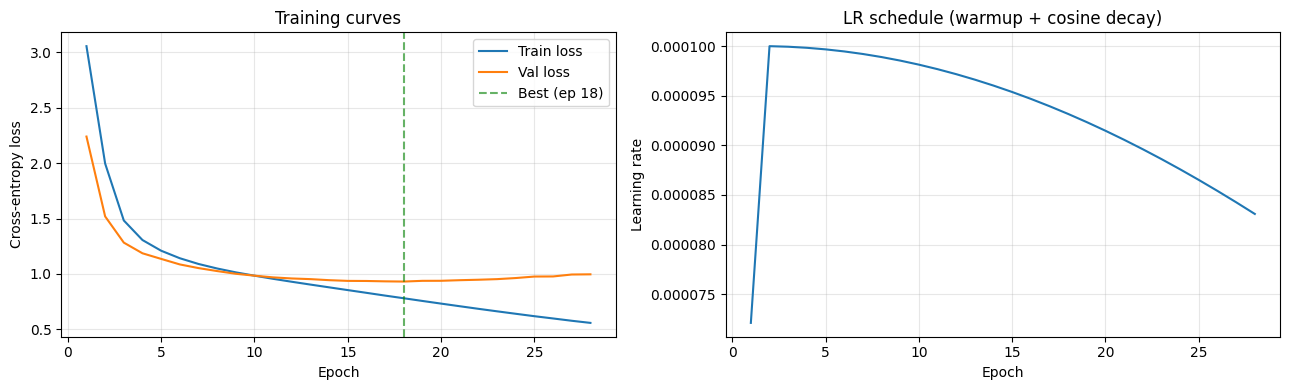

Epochs completed: 28
Best val loss:    0.9307  (epoch 18)
Final train loss: 0.5575


In [8]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

log_path = Path(f'models/{RUN_NAME}/train_log.jsonl')
assert log_path.exists(), f'Log not found at {log_path} — has training started?'

entries = [json.loads(line) for line in log_path.read_text().strip().splitlines()]
epochs      = [e['epoch']      for e in entries]
train_loss  = [e['train_loss'] for e in entries]
val_loss    = [e['val_loss']   for e in entries]
lrs         = [e['lr']         for e in entries]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, train_loss, label='Train loss')
ax1.plot(epochs, val_loss,   label='Val loss')
best_epoch = epochs[val_loss.index(min(val_loss))]
ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.6, label=f'Best (ep {best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Training curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, lrs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning rate')
ax2.set_title('LR schedule (warmup + cosine decay)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'models/{RUN_NAME}/training_curves.png', dpi=150)
plt.show()

print(f'Epochs completed: {len(epochs)}')
print(f'Best val loss:    {min(val_loss):.4f}  (epoch {best_epoch})')
print(f'Final train loss: {train_loss[-1]:.4f}')

## 6 — Quick generation sanity-check

Loads the best checkpoint and generates one tune. This is just a smoke-test to confirm the checkpoint is valid — a proper generation script (`src/generate.py`) comes later.

In [9]:
import torch
import yaml
from src.model import build_model
from src.tokenizer import ABCTokenizer

# ── Generation parameters ────────────────────────────────────────────────────
GEN_TYPE        = 'reel'
GEN_KEY         = 'Gmajor'
GEN_METER       = '4/4'
TEMPERATURE     = 0.8
TOP_K           = 50
MAX_NEW_TOKENS  = 256
# ─────────────────────────────────────────────────────────────────────────────

device    = torch.device('cuda')
ckpt_path = f'models/{RUN_NAME}/best.pt'

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)

tokenizer = ABCTokenizer.load(f'models/{RUN_NAME}/tokenizer.pkl')
model     = build_model(cfg, vocab_size=len(tokenizer)).to(device)
ckpt      = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"] + 1}, val loss {ckpt["val_loss"]:.4f}')

Loaded checkpoint from epoch 18, val loss 0.9307


In [10]:
import torch.nn.functional as F

def generate(
    model, tokenizer, tune_type, key, meter,
    temperature=0.8, top_k=50, max_new_tokens=256,
):
    """Simple autoregressive sampling (top-k). Full generation in src/generate.py."""
    # Seed with conditioning prefix + BOS
    prompt_ids = tokenizer.encode('', tune_type, key, meter, add_eos=False)
    ids = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(ids)               # (1, T, V)
            logits = logits[:, -1, :]         # last position: (1, V)

            # Top-k filtering
            if top_k > 0:
                vals, _ = torch.topk(logits, top_k)
                logits[logits < vals[:, -1:]] = float('-inf')

            probs  = F.softmax(logits / temperature, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

            if next_id.item() == tokenizer.eos_id:
                break
            ids = torch.cat([ids, next_id], dim=1)

    return tokenizer.decode_to_abc(ids[0].tolist())


abc = generate(
    model, tokenizer,
    tune_type=GEN_TYPE, key=GEN_KEY, meter=GEN_METER,
    temperature=TEMPERATURE, top_k=TOP_K, max_new_tokens=MAX_NEW_TOKENS,
)

print(f'X:1')
print(f'T:Generated {GEN_TYPE}')
print(f'M:{GEN_METER}')
print(f'L:1/8')
print(f'K:{GEN_KEY}')
print(abc)

X:1
T:Generated reel
M:4/4
L:1/8
K:Gmajor
G2 B G B d d B | G A B G A G E F | G2 B G B d d B | A B A G E G D E | G2 B G B d d B | G A B G A G E F | G2 B G B d d B | A B A G E G G2 || (3 B c d e f g2 e f | (3 g f e d B A G E G | (3 B c d e f g2 f g | (3 a b a g e a a f | (3 g f e f d e d B d | (3 g f e d B A G E F | G A B G B d d B | A B A G E G G2 ||


In [11]:
abc = generate(
    model, tokenizer,
    tune_type='jig', key=GEN_KEY, meter='6/8',
    temperature=TEMPERATURE, top_k=TOP_K, max_new_tokens=MAX_NEW_TOKENS,
)

print(f'X:1')
print(f'T:Generated {GEN_TYPE}')
print(f'M:{GEN_METER}')
print(f'L:1/8')
print(f'K:{GEN_KEY}')
print(abc)

X:1
T:Generated reel
M:4/4
L:1/8
K:Gmajor
B A | G E D G2 A | B2 d c B A | G E D G2 A | B A B G B A | G E D G2 A | B2 d c B A | B A B A G E | G A G G B A | G E D G2 A | B2 d c B A | B d B c B A | B A B G B d | e f g d e d | B2 d c B A | B A B A G E | G A G G B A | |: G B/ c/ d g f g | a f d c B A | G B/ c/ d g f g | a f d d2 e | f a f g f e | d B A G A B | B A B A G E | G A G G B A :|


In [15]:
from google.colab import userdata
import os

# 1. Setup authentication
token = userdata.get('GITHUB_TOKEN')
!git config --global user.email "afm2425@gmail.com"
!git config --global user.name "Andrew McKnight"

remote_url = GITHUB_URL.replace('https://', f'https://{token}@')
!git remote set-url origin {remote_url}

# 2. Fully reset the index to match the remote main (start over)
!git reset --mixed origin/main

# 3. Create a clean .gitignore
with open('.gitignore', 'w') as f:
    f.write('models/large/*.pt\n')
    f.write('models/large/*.pkl\n')
    f.write('models/large/latest.pt\n')
    f.write('models/large/best.pt\n')

# 4. Remove models/large from tracking entirely
!git rm -r --cached models/large/ || true

# 5. Add only what we want and push
!git add .
!git commit -m "Clean push: excluding model weights"
!git push origin main --force
```

error: the following files have staged content different from both the
file and the HEAD:
    models/large/best.pt
    models/large/latest.pt
    models/large/tokenizer.pkl
    models/large/train_log.jsonl
    models/large/training_curves.png
(use -f to force removal)
[main 0d887ed] Large training run (excluding heavy weights)
 14 files changed, 32 insertions(+), 1305 deletions(-)
 create mode 100644 .gitignore
 create mode 100644 models/large/best.pt
 create mode 100644 models/large/latest.pt
 create mode 100644 models/large/tokenizer.pkl
 create mode 100644 models/large/train_log.jsonl
 create mode 100644 models/large/training_curves.png
 rewrite notebooks/memorization_check.ipynb (97%)
 rewrite notebooks/train_colab.ipynb (98%)
 create mode 100644 src/__pycache__/evaluate.cpython-312.pyc
Enumerating objects: 29, done.
Counting objects: 100% (29/29), done.
Delta compression using up to 48 threads
Compressing objects: 100% (20/20), done.
error: RPC failed; HTTP 408 curl 22 The request